In [1]:
import pandas as pd
import requests
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully")

All libraries loaded successfully


In [2]:
# HCAHPS data from CMS
url = "https://data.cms.gov/provider-data/sites/default/files/resources/092256becd267d9eecca15f834f47d6e_1657632000/HCAHPS-Hospital.csv"

print("Loading HCAHPS data...")
df = pd.read_csv(r"C:\Users\kaitl\Downloads\HCAHPS-Hospital.csv", low_memory = False)
print(f"Shape: {df.shape}")
print(f"\nColumns:")
for col in df.columns.tolist():
    print(col)

Loading HCAHPS data...
Shape: (325652, 22)

Columns:
Facility ID
Facility Name
Address
City/Town
State
ZIP Code
County/Parish
Telephone Number
HCAHPS Measure ID
HCAHPS Question
HCAHPS Answer Description
Patient Survey Star Rating
Patient Survey Star Rating Footnote
HCAHPS Answer Percent
HCAHPS Answer Percent Footnote
HCAHPS Linear Mean Value
Number of Completed Surveys
Number of Completed Surveys Footnote
Survey Response Rate Percent
Survey Response Rate Percent Footnote
Start Date
End Date


In [3]:
# Data is in long format, need to convert to wide, each hospital as one row.
print("Unique HCAHPS Measures:")
print(df['HCAHPS Measure ID'].unique())
print(f"\nTotal unique hospitals: {df['Facility ID'].nunique()}")
print(f"\nDate range:")
print(df[['Start Date', 'End Date']].drop_duplicates())

Unique HCAHPS Measures:
['H_COMP_1_A_P' 'H_COMP_1_SN_P' 'H_COMP_1_U_P' 'H_COMP_1_LINEAR_SCORE'
 'H_COMP_1_STAR_RATING' 'H_NURSE_RESPECT_A_P' 'H_NURSE_RESPECT_SN_P'
 'H_NURSE_RESPECT_U_P' 'H_NURSE_LISTEN_A_P' 'H_NURSE_LISTEN_SN_P'
 'H_NURSE_LISTEN_U_P' 'H_NURSE_EXPLAIN_A_P' 'H_NURSE_EXPLAIN_SN_P'
 'H_NURSE_EXPLAIN_U_P' 'H_COMP_2_A_P' 'H_COMP_2_SN_P' 'H_COMP_2_U_P'
 'H_COMP_2_LINEAR_SCORE' 'H_COMP_2_STAR_RATING' 'H_DOCTOR_RESPECT_A_P'
 'H_DOCTOR_RESPECT_SN_P' 'H_DOCTOR_RESPECT_U_P' 'H_DOCTOR_LISTEN_A_P'
 'H_DOCTOR_LISTEN_SN_P' 'H_DOCTOR_LISTEN_U_P' 'H_DOCTOR_EXPLAIN_A_P'
 'H_DOCTOR_EXPLAIN_SN_P' 'H_DOCTOR_EXPLAIN_U_P' 'H_COMP_5_A_P'
 'H_COMP_5_SN_P' 'H_COMP_5_U_P' 'H_COMP_5_LINEAR_SCORE'
 'H_COMP_5_STAR_RATING' 'H_MED_FOR_A_P' 'H_MED_FOR_SN_P' 'H_MED_FOR_U_P'
 'H_SIDE_EFFECTS_A_P' 'H_SIDE_EFFECTS_SN_P' 'H_SIDE_EFFECTS_U_P'
 'H_COMP_6_N_P' 'H_COMP_6_Y_P' 'H_COMP_6_LINEAR_SCORE'
 'H_COMP_6_STAR_RATING' 'H_DISCH_HELP_N_P' 'H_DISCH_HELP_Y_P'
 'H_SYMPTOMS_N_P' 'H_SYMPTOMS_Y_P' 'H_CLEAN_HSP_A_

In [4]:
key_measures_map = {
    'H_HSP_RATING_9_10': '9_10_rating_pct',
    'H_RECMND_DY': 'definitely_recommend_pct',
    'H_CLEAN_HSP_A_P': 'cleanliness_pct',
    'H_QUIET_HSP_A_P': 'quietness_pct',
    'H_COMP_1_A_P': 'nurse_comm_pct',
    'H_COMP_2_A_P': 'doctor_comm_pct',
    'H_COMP_5_A_P': 'medication_comm_pct',
}

# Pivot the percentage measures
df_filtered = df[df['HCAHPS Measure ID'].isin(key_measures_map.keys())].copy()
df_wide = df_filtered.pivot_table(
    index=['Facility ID', 'Facility Name', 'City/Town', 'State',
           'ZIP Code', 'Number of Completed Surveys', 'Survey Response Rate Percent'],
    columns='HCAHPS Measure ID',
    values='HCAHPS Answer Percent',
    aggfunc='first'
).reset_index()
df_wide.columns.name = None

# Retrieve star ratings separately from Patient Survey Star Rating column
star_df = df[df['HCAHPS Measure ID'] == 'H_STAR_RATING'][
    ['Facility ID', 'Patient Survey Star Rating']
].copy()
star_df = star_df.rename(columns={
    'Facility ID': 'Facility ID',
    'Patient Survey Star Rating': 'star_rating'
})
star_df['star_rating'] = pd.to_numeric(star_df['star_rating'], errors='coerce')

# Merge star ratings with our df.
df_wide = df_wide.merge(star_df, on='Facility ID', how='left')

# Rename columns for interpretability
df_wide = df_wide.rename(columns={
    **key_measures_map,
    'Facility ID': 'facility_id',
    'Facility Name': 'facility_name',
    'City/Town': 'city',
    'State': 'state',
    'ZIP Code': 'zip_code',
    'Number of Completed Surveys': 'completed_surveys',
    'Survey Response Rate Percent': 'response_rate_pct'
})

print(f"Shape: {df_wide.shape}")
print(f"Columns: {df_wide.columns.tolist()}")
print(f"\nMissing values:")
print(df_wide.isnull().sum())

Shape: (4789, 15)
Columns: ['facility_id', 'facility_name', 'city', 'state', 'zip_code', 'completed_surveys', 'response_rate_pct', 'cleanliness_pct', 'nurse_comm_pct', 'doctor_comm_pct', 'medication_comm_pct', '9_10_rating_pct', 'quietness_pct', 'definitely_recommend_pct', 'star_rating']

Missing values:
facility_id                    0
facility_name                  0
city                           0
state                          0
zip_code                       0
completed_surveys              0
response_rate_pct              0
cleanliness_pct                0
nurse_comm_pct                 0
doctor_comm_pct                0
medication_comm_pct            0
9_10_rating_pct                0
quietness_pct                  0
definitely_recommend_pct       0
star_rating                 1606
dtype: int64


In [5]:
# Drop obs missing percentages in our target
df_clean = df_wide.dropna(subset=['9_10_rating_pct']).copy()

# Convert numeric columns
num_cols = ['completed_surveys', 'response_rate_pct', 'cleanliness_pct',
            'nurse_comm_pct', 'doctor_comm_pct', 'medication_comm_pct',
            '9_10_rating_pct', 'quietness_pct', 'definitely_recommend_pct']

for col in num_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

print(f"Cleaned dataset: {len(df_clean)} hospitals")
print(f"Missing star ratings: {df_clean['star_rating'].isna().sum()}")
print(f"\nSummary stats:")
print(df_clean[['9_10_rating_pct', 'definitely_recommend_pct', 
                'cleanliness_pct', 'nurse_comm_pct', 
                'star_rating']].describe().round(1))

Cleaned dataset: 4789 hospitals
Missing star ratings: 1606

Summary stats:
       9_10_rating_pct  definitely_recommend_pct  cleanliness_pct  \
count           3961.0                    3961.0           3961.0   
mean              71.9                      70.6             73.6   
std                9.5                      10.3              8.8   
min               27.0                      25.0             40.0   
25%               66.0                      64.0             68.0   
50%               72.0                      71.0             73.0   
75%               78.0                      78.0             79.0   
max              100.0                     100.0            100.0   

       nurse_comm_pct  star_rating  
count          3961.0       3183.0  
mean             79.8          3.2  
std               6.1          0.9  
min              53.0          1.0  
25%              76.0          3.0  
50%              79.0          3.0  
75%              84.0          4.0  
max    

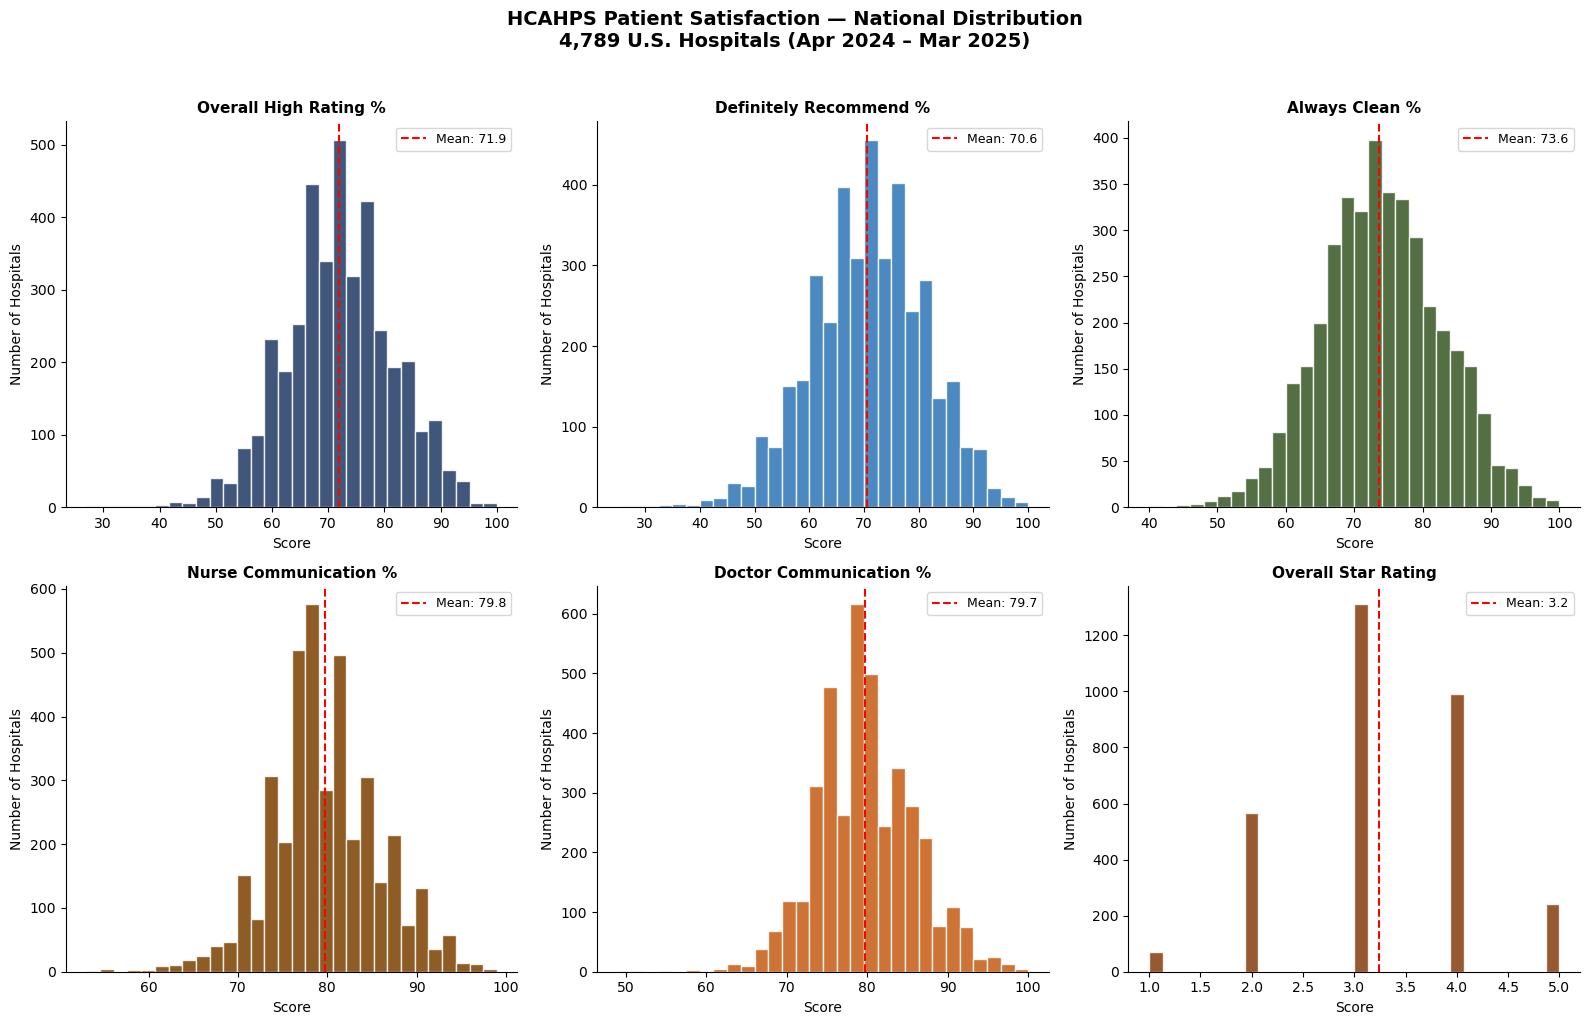

Charts saved!


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('HCAHPS Patient Satisfaction — National Distribution\n4,789 U.S. Hospitals (Apr 2024 – Mar 2025)', 
             fontsize=14, fontweight='bold', y=1.02)

plot_vars = [
    ('9_10_rating_pct', 'Overall High Rating %', '#1F3864'),
    ('definitely_recommend_pct', 'Definitely Recommend %', '#2E75B6'),
    ('cleanliness_pct', 'Always Clean %', '#375623'),
    ('nurse_comm_pct', 'Nurse Communication %', '#7B3F00'),
    ('doctor_comm_pct', 'Doctor Communication %', '#C55A11'),
    ('star_rating', 'Overall Star Rating', '#843C0C')
]

for ax, (col, title, color) in zip(axes.flatten(), plot_vars):
    data = df_clean[col].dropna()
    ax.hist(data, bins=30, color=color, alpha=0.85, edgecolor='white')
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():.1f}')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('Score')
    ax.set_ylabel('Number of Hospitals')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('hcahps_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved!")

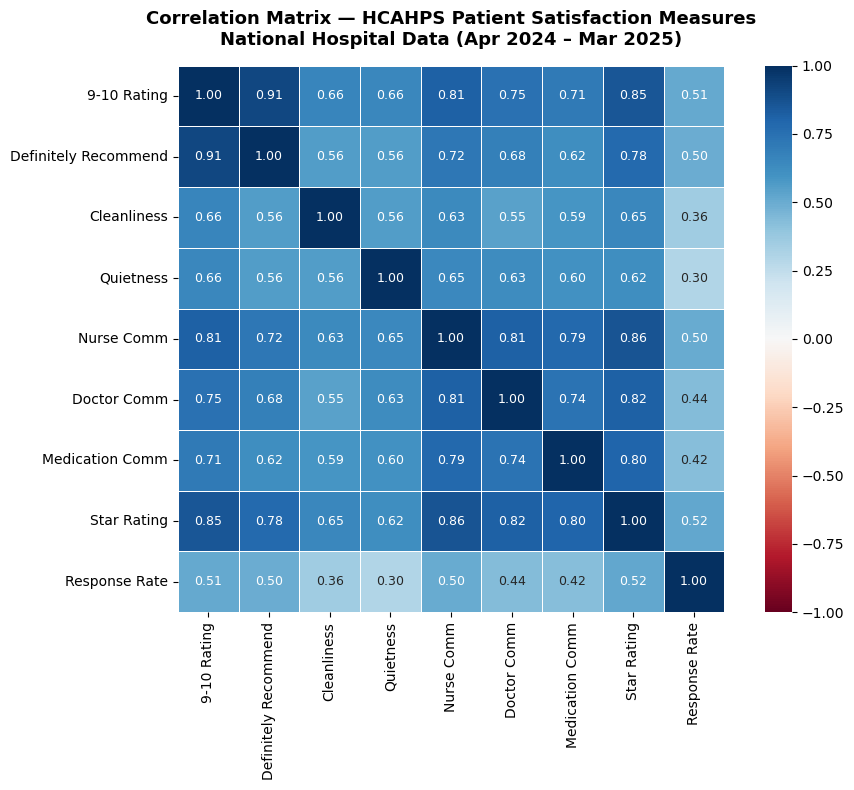

Correlation heatmap saved


In [7]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))

corr_cols = ['9_10_rating_pct', 'definitely_recommend_pct', 'cleanliness_pct', 
             'quietness_pct', 'nurse_comm_pct', 'doctor_comm_pct', 
             'medication_comm_pct', 'star_rating', 'response_rate_pct']

corr_labels = ['9-10 Rating', 'Definitely Recommend', 'Cleanliness', 
               'Quietness', 'Nurse Comm', 'Doctor Comm', 
               'Medication Comm', 'Star Rating', 'Response Rate']

corr_matrix = df_clean[corr_cols].corr()
corr_matrix.index = corr_labels
corr_matrix.columns = corr_labels

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f',
            cmap='RdBu',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5,
            ax=ax,
            annot_kws={'size': 9})

ax.set_title('Correlation Matrix — HCAHPS Patient Satisfaction Measures\nNational Hospital Data (Apr 2024 – Mar 2025)', 
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('hcahps_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Correlation heatmap saved")

In [8]:
# Note: Initial analysis showed negative correlations for recommend_pct
# Investigation showed I used H_RECMND_PY "probably yes" responses (weak positive)
# Corrected to H_RECMND_DY which captures "definitely yes" (strong positive recommendation)
# This is documented as an example of data validation during EDA

# Check what recommend measures are available
recommend_measures = df[df['HCAHPS Measure ID'].str.contains('RECMND', na=False)]
print(recommend_measures[['HCAHPS Measure ID', 'HCAHPS Question', 
                           'HCAHPS Answer Description']].drop_duplicates())

# We accidentally used H_RECMND_PY instead of H_RECMND_DY: probably vs. definitely. 
# I went back and changed the variable assignment in our key measures...

        HCAHPS Measure ID                                    HCAHPS Question  \
62            H_RECMND_DN  Patients who reported NO, they would probably ...   
63            H_RECMND_DY  Patients who reported YES, they would definite...   
64            H_RECMND_PY  Patients who reported YES, they would probably...   
65  H_RECMND_LINEAR_SCORE             Recommend hospital - linear mean score   
66   H_RECMND_STAR_RATING                   Recommend hospital - star rating   

                            HCAHPS Answer Description  
62  "NO", patients would not recommend the hospita...  
63  "YES", patients would definitely recommend the...  
64  "YES", patients would probably recommend the h...  
65             Recommend hospital - linear mean score  
66                   Recommend hospital - star rating  


In [9]:
# Continuing analysis beyond survey responses.

hosp_info = pd.read_csv(r'C:\Users\kaitl\Downloads\Hospital_General_Information.csv', low_memory=False)
print(f"Shape: {hosp_info.shape}")
print(f"\nColumns:")
for col in hosp_info.columns.tolist():
    print(col)

Shape: (5426, 38)

Columns:
Facility ID
Facility Name
Address
City/Town
State
ZIP Code
County/Parish
Telephone Number
Hospital Type
Hospital Ownership
Emergency Services
Meets criteria for birthing friendly designation
Hospital overall rating
Hospital overall rating footnote
MORT Group Measure Count
Count of Facility MORT Measures
Count of MORT Measures Better
Count of MORT Measures No Different
Count of MORT Measures Worse
MORT Group Footnote
Safety Group Measure Count
Count of Facility Safety Measures
Count of Safety Measures Better
Count of Safety Measures No Different
Count of Safety Measures Worse
Safety Group Footnote
READM Group Measure Count
Count of Facility READM Measures
Count of READM Measures Better
Count of READM Measures No Different
Count of READM Measures Worse
READM Group Footnote
Pt Exp Group Measure Count
Count of Facility Pt Exp Measures
Pt Exp Group Footnote
TE Group Measure Count
Count of Facility TE Measures
TE Group Footnote


In [10]:
# Exploring all relevant columns
hosp_subset = hosp_info[[
    'Facility ID',
    'Hospital Type',
    'Hospital Ownership',
    'Emergency Services',
    'Hospital overall rating',
    'Count of MORT Measures Better',
    'Count of MORT Measures No Different',
    'Count of MORT Measures Worse',
    'Count of Safety Measures Better',
    'Count of Safety Measures No Different',
    'Count of Safety Measures Worse',
    'Count of READM Measures Better',
    'Count of READM Measures No Different',
    'Count of READM Measures Worse',
    'Count of Facility Pt Exp Measures',
    'TE Group Measure Count'
]].copy()

# Renaming for cleanliness
hosp_subset = hosp_subset.rename(columns={
    'Facility ID': 'facility_id',
    'Hospital Type': 'hospital_type',
    'Hospital Ownership': 'ownership',
    'Emergency Services': 'emergency_services',
    'Hospital overall rating': 'cms_overall_rating',
    'Count of MORT Measures Better': 'mort_better',
    'Count of MORT Measures No Different': 'mort_avg',
    'Count of MORT Measures Worse': 'mort_worse',
    'Count of Safety Measures Better': 'safety_better',
    'Count of Safety Measures No Different': 'safety_avg',
    'Count of Safety Measures Worse': 'safety_worse',
    'Count of READM Measures Better': 'readm_better',
    'Count of READM Measures No Different': 'readm_avg',
    'Count of READM Measures Worse': 'readm_worse',
    'Count of Facility Pt Exp Measures': 'pt_exp_measure_count',
    'TE Group Measure Count': 'timely_care_measure_count'
})

# Check values before merging
print("Hospital Types:")
print(hosp_subset['hospital_type'].value_counts())
print("\nOwnership Types:")
print(hosp_subset['ownership'].value_counts())
print("\nEmergency Services:")
print(hosp_subset['emergency_services'].value_counts())
print("\nCMS Overall Rating:")
print(hosp_subset['cms_overall_rating'].value_counts().sort_index())
print(f"\nShape: {hosp_subset.shape}")

Hospital Types:
hospital_type
Acute Care Hospitals                    3116
Critical Access Hospitals               1376
Psychiatric                              633
Acute Care - Veterans Administration     132
Childrens                                 94
Rural Emergency Hospital                  39
Acute Care - Department of Defense        32
Long-term                                  4
Name: count, dtype: int64

Ownership Types:
ownership
Voluntary non-profit - Private                 2304
Proprietary                                    1069
Government - Hospital District or Authority     519
Government - Local                              401
Voluntary non-profit - Other                    355
Voluntary non-profit - Church                   271
Government - State                              209
Veterans Health Administration                  132
Physician                                        76
Government - Federal                             43
Department of Defense               

In [11]:
# Combining some variables:
# Hospital type
def simplify_hospital_type(t):
    if 'Acute Care' in str(t):
        return 'Acute Care'
    elif 'Critical Access' in str(t):
        return 'Critical Access'
    elif 'Psychiatric' in str(t):
        return 'Psychiatric'
    elif 'Childrens' in str(t):
        return 'Children\'s'
    else:
        return 'Other'

# Ownership
def simplify_ownership(o):
    if 'non-profit' in str(o).lower():
        return 'Nonprofit'
    elif 'Proprietary' in str(o) or 'Physician' in str(o):
        return 'For-Profit'
    elif 'Veterans' in str(o) or 'Defense' in str(o):
        return 'VA/DOD'
    else:
        return 'Government'

hosp_subset['hospital_type_simple'] = hosp_subset['hospital_type'].apply(simplify_hospital_type)
hosp_subset['ownership_simple'] = hosp_subset['ownership'].apply(simplify_ownership)

# Convert numeric columns
num_cols = ['mort_better', 'mort_avg', 'mort_worse',
            'safety_better', 'safety_avg', 'safety_worse',
            'readm_better', 'readm_avg', 'readm_worse',
            'pt_exp_measure_count', 'timely_care_measure_count']

for col in num_cols:
    hosp_subset[col] = pd.to_numeric(hosp_subset[col], errors='coerce')

hosp_subset['cms_overall_rating'] = pd.to_numeric(
    hosp_subset['cms_overall_rating'], errors='coerce')

# View new simplified categories
print("Simplified Hospital Types:")
print(hosp_subset['hospital_type_simple'].value_counts())
print("\nSimplified Ownership:")
print(hosp_subset['ownership_simple'].value_counts())

# Merge with our HCAHPS data
df_merged = df_clean.merge(hosp_subset, on='facility_id', how='inner')
print(f"\nMerged shape: {df_merged.shape}")
print(f"Columns: {df_merged.columns.tolist()}")

Simplified Hospital Types:
hospital_type_simple
Acute Care         3280
Critical Access    1376
Psychiatric         633
Children's           94
Other                43
Name: count, dtype: int64

Simplified Ownership:
ownership_simple
Nonprofit     2930
Government    1187
For-Profit    1145
VA/DOD         164
Name: count, dtype: int64

Merged shape: (4789, 32)
Columns: ['facility_id', 'facility_name', 'city', 'state', 'zip_code', 'completed_surveys', 'response_rate_pct', 'cleanliness_pct', 'nurse_comm_pct', 'doctor_comm_pct', 'medication_comm_pct', '9_10_rating_pct', 'quietness_pct', 'definitely_recommend_pct', 'star_rating', 'hospital_type', 'ownership', 'emergency_services', 'cms_overall_rating', 'mort_better', 'mort_avg', 'mort_worse', 'safety_better', 'safety_avg', 'safety_worse', 'readm_better', 'readm_avg', 'readm_worse', 'pt_exp_measure_count', 'timely_care_measure_count', 'hospital_type_simple', 'ownership_simple']


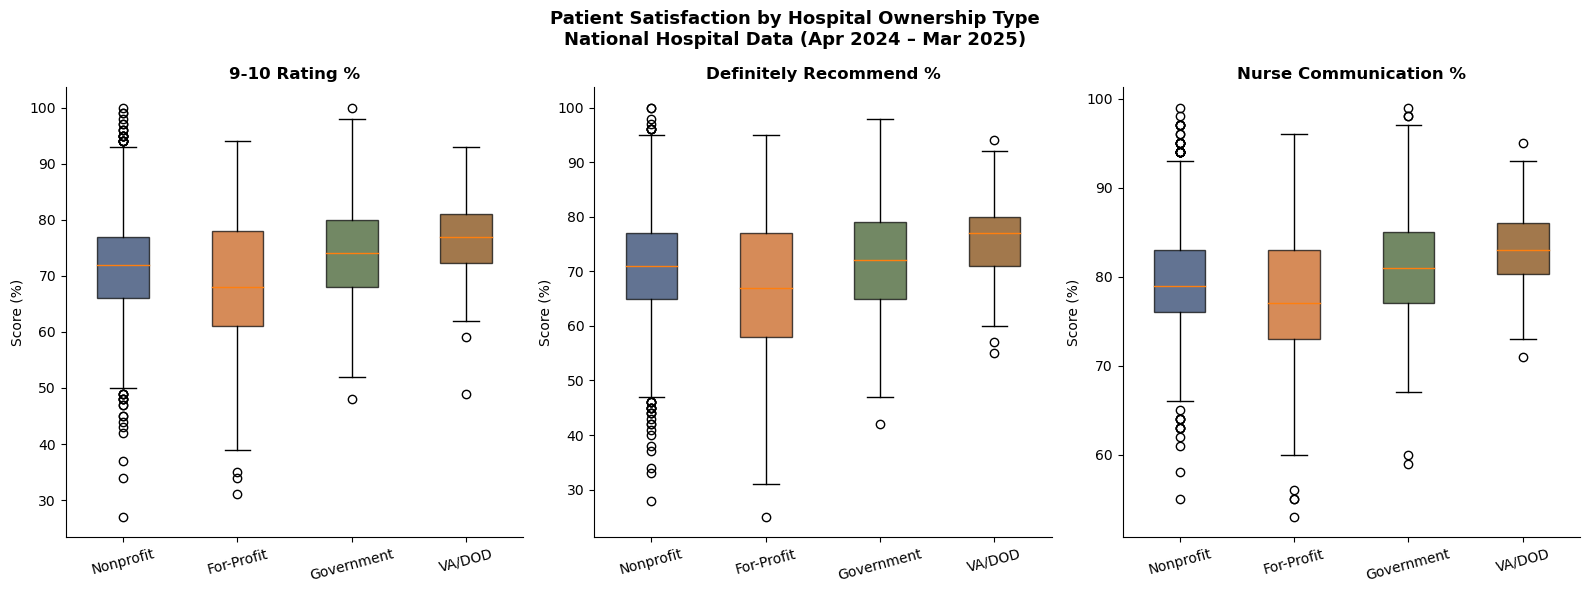

VA/DOD are consistently outperforming other types.
Also note that Non-Profits are not outperforming For-Profit, as research often suggests.


In [12]:
# Satisfaction by Ownership types
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Patient Satisfaction by Hospital Ownership Type\nNational Hospital Data (Apr 2024 – Mar 2025)',
             fontsize=13, fontweight='bold')

metrics = [
    ('9_10_rating_pct', '9-10 Rating %'),
    ('definitely_recommend_pct', 'Definitely Recommend %'),
    ('nurse_comm_pct', 'Nurse Communication %')
]

ownership_order = ['Nonprofit', 'For-Profit', 'Government', 'VA/DOD']
colors = ['#1F3864', '#C55A11', '#375623', '#7B3F00']

for ax, (col, title) in zip(axes, metrics):
    data_by_ownership = [
        df_merged[df_merged['ownership_simple'] == o][col].dropna()
        for o in ownership_order
    ]
    bp = ax.boxplot(data_by_ownership, labels=ownership_order, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Score (%)')
    ax.tick_params(axis='x', rotation=15)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('satisfaction_by_ownership.png', dpi=150, bbox_inches='tight')
plt.show()

print("VA/DOD are consistently outperforming other types.")
print("Also note that Non-Profits are not outperforming For-Profit, as research often suggests.")

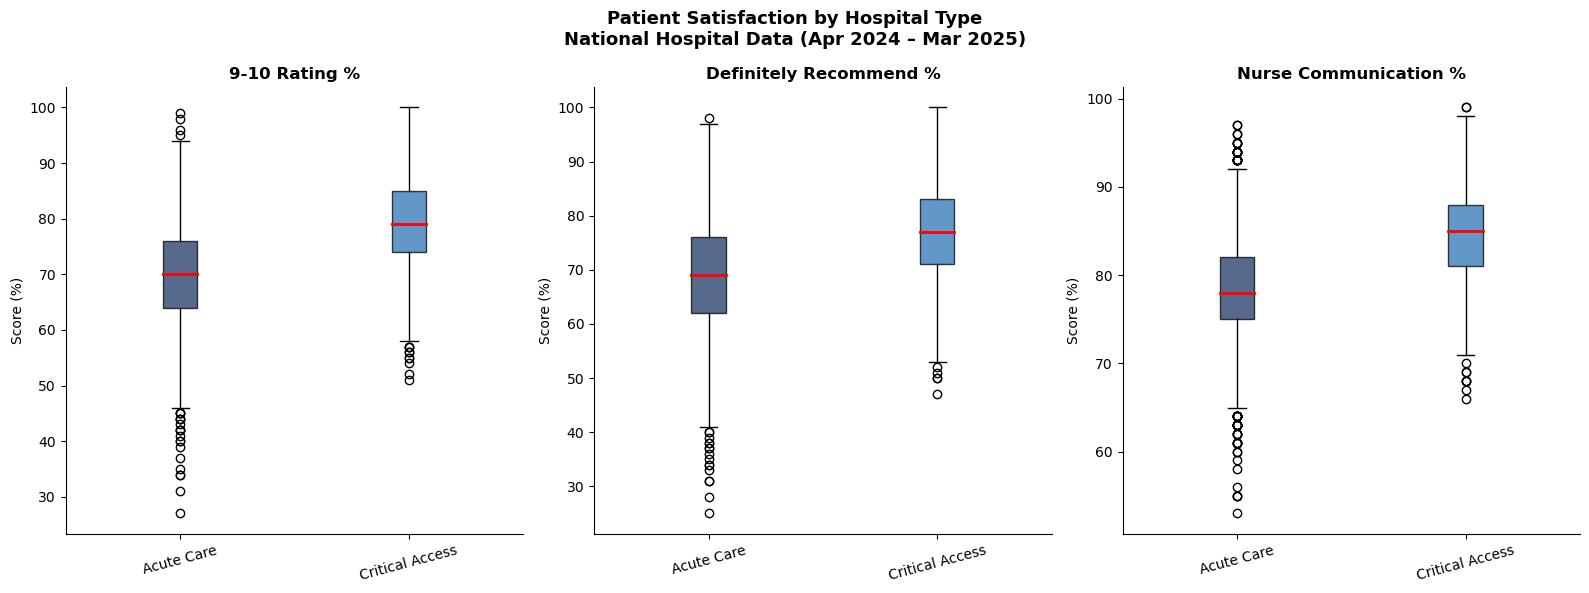

Critical Access (smaller rural facilities) displays higher patient satisfaction scores with smaller variance than larger Acute Care facilities.


In [13]:
# Hospital Types
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Patient Satisfaction by Hospital Type\nNational Hospital Data (Apr 2024 – Mar 2025)',
             fontsize=13, fontweight='bold')

type_order = ['Acute Care', 'Critical Access']
colors = ['#1F3864', '#2E75B6']

for ax, (col, title) in zip(axes, metrics):
    data_by_type = [
        df_merged[df_merged['hospital_type_simple'] == t][col].dropna()
        for t in type_order
    ]
    bp = ax.boxplot(data_by_type, labels=type_order, patch_artist=True,
                    medianprops=dict(color='red', linewidth=2))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Score (%)')
    ax.tick_params(axis='x', rotation=15)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('satisfaction_by_hospital_type.png', dpi=150, bbox_inches='tight')
plt.show()
print("Critical Access (smaller rural facilities) displays higher patient satisfaction scores with smaller variance than larger Acute Care facilities.")

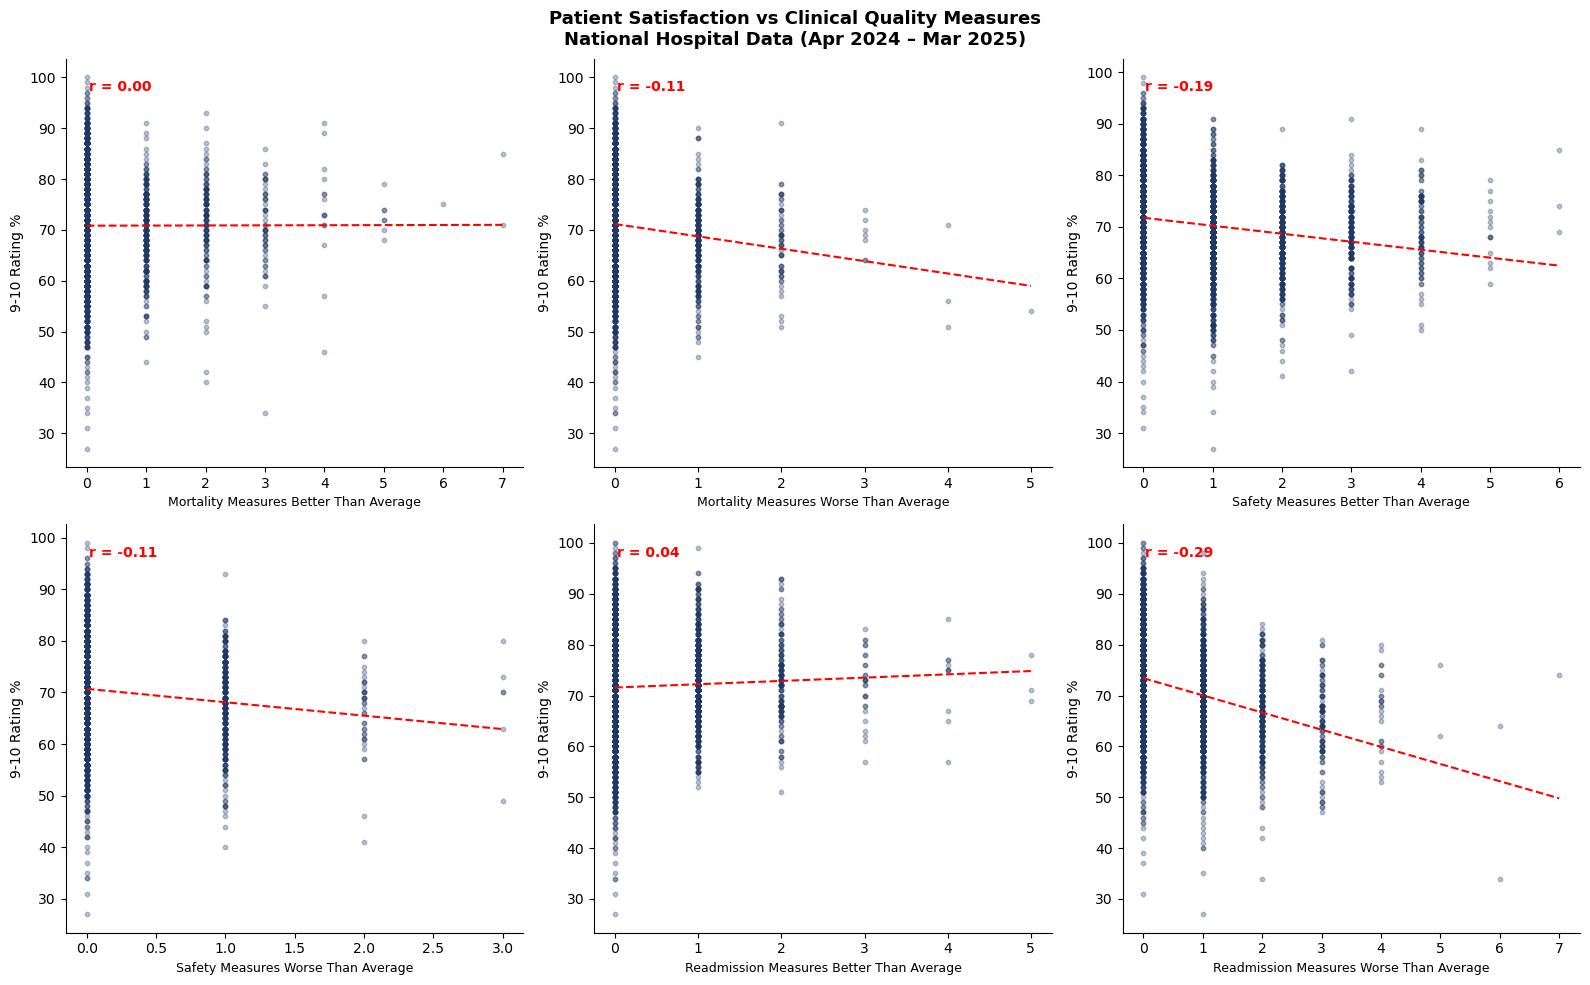

Surprisingly, hospitals with better-than-average safety have lower satisfaction scores.
Higher readmission rates correlate most strongly with worse satisfaction scores.
Overall, clinical quality measures do not tend to correlate with patient satisfaction scores.


In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Patient Satisfaction vs Clinical Quality Measures\nNational Hospital Data (Apr 2024 – Mar 2025)',
             fontsize=13, fontweight='bold')

quality_vars = [
    ('mort_better', 'Mortality Measures Better Than Average'),
    ('mort_worse', 'Mortality Measures Worse Than Average'),
    ('safety_better', 'Safety Measures Better Than Average'),
    ('safety_worse', 'Safety Measures Worse Than Average'),
    ('readm_better', 'Readmission Measures Better Than Average'),
    ('readm_worse', 'Readmission Measures Worse Than Average'),
]

for ax, (col, title) in zip(axes.flatten(), quality_vars):
    data = df_merged[[col, '9_10_rating_pct']].dropna()
    ax.scatter(data[col], data['9_10_rating_pct'], 
               alpha=0.3, s=10, color='#1F3864')
    
    # Add trend line
    z = np.polyfit(data[col], data['9_10_rating_pct'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(data[col].min(), data[col].max(), 100)
    ax.plot(x_line, p(x_line), color='red', linewidth=1.5, linestyle='--')
    
    # Add correlation value
    corr = data[col].corr(data['9_10_rating_pct'])
    ax.text(0.05, 0.92, f'r = {corr:.2f}', transform=ax.transAxes,
            fontsize=10, color='red', fontweight='bold')
    
    ax.set_xlabel(title, fontsize=9)
    ax.set_ylabel('9-10 Rating %')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('satisfaction_vs_quality.png', dpi=150, bbox_inches='tight')
plt.show()
print("Surprisingly, hospitals with better-than-average safety have lower satisfaction scores.")
print("Higher readmission rates correlate most strongly with worse satisfaction scores.")
print("Overall, clinical quality measures do not tend to correlate with patient satisfaction scores.")

In [15]:
# create a regression model  to identify strongest predictors
# data setup

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Select features for the model
feature_cols = [
    'nurse_comm_pct', 'doctor_comm_pct', 'medication_comm_pct',
    'cleanliness_pct', 'quietness_pct', 'definitely_recommend_pct',
    'response_rate_pct', 'completed_surveys',
    'mort_better', 'mort_worse', 'safety_better', 'safety_worse',
    'readm_better', 'readm_worse'
]

# Add dummy variables for ownership and hospital type
df_model = pd.get_dummies(df_merged, 
                           columns=['ownership_simple', 'hospital_type_simple'],
                           drop_first=True)

# Get the dummy column names that were created
dummy_cols = [c for c in df_model.columns if 'ownership_simple_' in c or 'hospital_type_simple_' in c]
feature_cols = feature_cols + dummy_cols

# Drop rows with any missing values in features or target
model_data = df_model[feature_cols + ['9_10_rating_pct']].dropna()

X = model_data[feature_cols]
y = model_data['9_10_rating_pct']

print(f"Model dataset: {len(model_data)} hospitals")
print(f"Features: {len(feature_cols)}")
print(f"\nFeature list:")
for f in feature_cols:
    print(f" - {f}")

Model dataset: 3048 hospitals
Features: 20

Feature list:
 - nurse_comm_pct
 - doctor_comm_pct
 - medication_comm_pct
 - cleanliness_pct
 - quietness_pct
 - definitely_recommend_pct
 - response_rate_pct
 - completed_surveys
 - mort_better
 - mort_worse
 - safety_better
 - safety_worse
 - readm_better
 - readm_worse
 - ownership_simple_Government
 - ownership_simple_Nonprofit
 - ownership_simple_VA/DOD
 - hospital_type_simple_Children's
 - hospital_type_simple_Critical Access
 - hospital_type_simple_Other


In [16]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit lr model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Evaluate
y_pred = model.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score: {r2:.3f}")
print(f"RMSE: {rmse:.2f} percentage points")

# Feature importance
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(f"\nFeature Coefficients (sorted by absolute value):")
print(coef_df.to_string(index=False))
print("\nR-squared of 0.904 explains 90.4% of the variance in pt satisfaction scores.")
print("RMSE of 2.63 means our predictions are within 2-3 points of actuals.")
print("\ndefinitely_recommend_pct (5.56) is intuitively the strongest predictor. Nurse communication rating (1.44) is the next strongest predictor, followed by Cleanliness and Quietness (0.79, 0.77).")

R² Score: 0.904
RMSE: 2.63 percentage points

Feature Coefficients (sorted by absolute value):
                             Feature  Coefficient
            definitely_recommend_pct     5.555840
                      nurse_comm_pct     1.436468
                     cleanliness_pct     0.788134
                       quietness_pct     0.769286
                     doctor_comm_pct     0.414311
                 medication_comm_pct     0.263185
                         readm_worse    -0.203208
          ownership_simple_Nonprofit     0.140255
                   response_rate_pct     0.084498
         ownership_simple_Government     0.080992
hospital_type_simple_Critical Access     0.077077
                       safety_better    -0.067765
             ownership_simple_VA/DOD     0.066008
                        safety_worse    -0.050002
                   completed_surveys     0.048750
                         mort_better     0.023466
                        readm_better    -0.019213
     

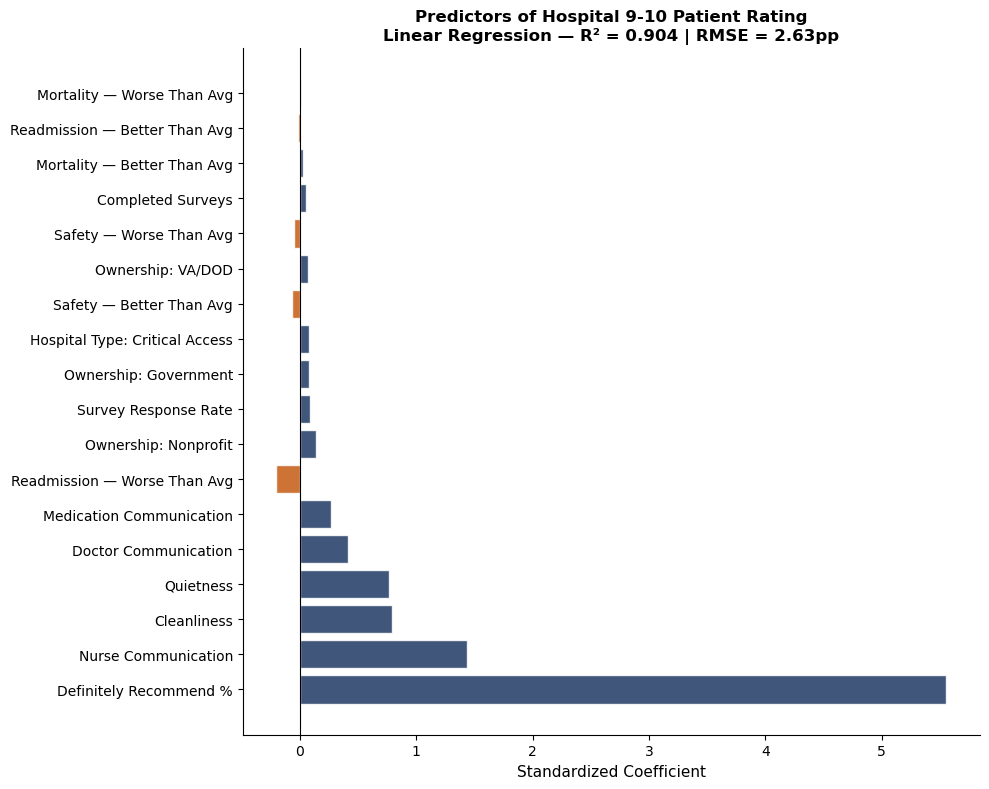

In [17]:
fig, ax = plt.subplots(figsize=(10, 8))

# Filter to meaningful coefficients only
coef_plot = coef_df[coef_df['Coefficient'].abs() > 0.01].copy()

colors = ['#1F3864' if x > 0 else '#C55A11' for x in coef_plot['Coefficient']]

bars = ax.barh(coef_plot['Feature'], coef_plot['Coefficient'], 
               color=colors, alpha=0.85, edgecolor='white')

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Standardized Coefficient', fontsize=11)
ax.set_title(f'Predictors of Hospital 9-10 Patient Rating\nLinear Regression — R² = {r2:.3f} | RMSE = {rmse:.2f}pp',
             fontsize=12, fontweight='bold')

# Clean up feature names for display
clean_labels = {
    'definitely_recommend_pct': 'Definitely Recommend %',
    'nurse_comm_pct': 'Nurse Communication',
    'cleanliness_pct': 'Cleanliness',
    'quietness_pct': 'Quietness',
    'doctor_comm_pct': 'Doctor Communication',
    'medication_comm_pct': 'Medication Communication',
    'readm_worse': 'Readmission — Worse Than Avg',
    'ownership_simple_Nonprofit': 'Ownership: Nonprofit',
    'response_rate_pct': 'Survey Response Rate',
    'ownership_simple_Government': 'Ownership: Government',
    'hospital_type_simple_Critical Access': 'Hospital Type: Critical Access',
    'safety_better': 'Safety — Better Than Avg',
    'ownership_simple_VA/DOD': 'Ownership: VA/DOD',
    'safety_worse': 'Safety — Worse Than Avg',
    'completed_surveys': 'Completed Surveys',
    'mort_better': 'Mortality — Better Than Avg',
    'readm_better': 'Readmission — Better Than Avg',
    'mort_worse': 'Mortality — Worse Than Avg'
}

ax.set_yticklabels([clean_labels.get(f, f) for f in coef_plot['Feature']])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('regression_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# validate LR findings with Random Forest model.
from sklearn.ensemble import RandomForestRegressor

# Fit RF model
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Evaluate
y_pred_rf = rf_model.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"Random Forest R²: {r2_rf:.3f}")
print(f"Random Forest RMSE: {rmse_rf:.2f} percentage points")
print(f"\nLinear Regression R²: {r2:.3f}")
print(f"Linear Regression RMSE: {rmse:.2f} percentage points")

# Feature importance
rf_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\nRandom Forest Feature Importance (top 10):")
print(rf_importance.head(10).to_string(index=False))
print("\nSimilar to the Linear Regression model, definitely_recommend_pct is the strongest predictor of high patient satisfaction rates.")
print("More importantly, Nurse Communication is the next strongest predictor (0.065). Quietness, Medication Communications, and Cleanliness follow (0.015, 0.014, 0.013).")
print("Based on these findings, hospitals looking to improve their patient satisfaction scores should prioritize Nurse selection and training, specifically in patient care and communication. Hospitals should also prioritize a clean and quiet environment, and exceptional communication surrounding patient medication.")

Random Forest R²: 0.894
Random Forest RMSE: 2.77 percentage points

Linear Regression R²: 0.904
Linear Regression RMSE: 2.63 percentage points

Random Forest Feature Importance (top 10):
                 Feature  Importance
definitely_recommend_pct    0.866839
          nurse_comm_pct    0.065006
           quietness_pct    0.015435
     medication_comm_pct    0.014418
         cleanliness_pct    0.012683
         doctor_comm_pct    0.008326
       completed_surveys    0.008044
       response_rate_pct    0.004150
           safety_better    0.001227
             readm_worse    0.001129

Similar to the Linear Regression model, definitely_recommend_pct is the strongest predictor of high patient satisfaction rates.
More importantly, Nurse Communication is the next strongest predictor (0.065). Quietness, Medication Communications, and Cleanliness follow (0.015, 0.014, 0.013).
Based on these findings, hospitals looking to improve their patient satisfaction scores should prioritize Nurse se

In [19]:
# Model comparision summary
from sklearn.metrics import mean_absolute_error

# Calculate all metrics for both models
def model_metrics(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    mspe = mse  # MSPE = MSE on test set (prediction error)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{'='*40}")
    print(f"{model_name}")
    print(f"{'='*40}")
    print(f"R²:    {r2:.4f}")
    print(f"MSPE:  {mspe:.4f}")
    print(f"RMSE:  {rmse:.4f} percentage points")
    print(f"MAE:   {mae:.4f} percentage points")
    return {'Model': model_name, 'R2': r2, 'MSPE': mspe, 
            'RMSE': rmse, 'MAE': mae}

lr_metrics = model_metrics(y_test, y_pred, "Linear Regression")
rf_metrics = model_metrics(y_test, y_pred_rf, "Random Forest")

# Summary comparison table
comparison = pd.DataFrame([lr_metrics, rf_metrics])
comparison = comparison.round(4)
print(f"\n{'='*40}")
print("MODEL COMPARISON SUMMARY")
print(f"{'='*40}")
print(comparison.to_string(index=False))


Linear Regression
R²:    0.9041
MSPE:  6.9107
RMSE:  2.6288 percentage points
MAE:   1.9391 percentage points

Random Forest
R²:    0.8936
MSPE:  7.6672
RMSE:  2.7690 percentage points
MAE:   2.0181 percentage points

MODEL COMPARISON SUMMARY
            Model     R2   MSPE   RMSE    MAE
Linear Regression 0.9041 6.9107 2.6288 1.9391
    Random Forest 0.8936 7.6672 2.7690 2.0181
